# HW4 – Isabel Taylor

My code is here: [link](https://github.com/izzietaylor123/DS4400/blob/main/HW4/notebook4.ipynb)

 
### Data:
 The dataset for this assignment is the SPAMBASE dataset from the UCI repository available at [here](https://archive.ics.uci.edu/dataset/94/spambase). The first 57 columns are features counting word frequencies (see documentation [here](https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.names)). The last column indicates 1 for the SPAM class and 0 for the HAM class.
 The Mushroom dataset from the UCI repository available [here](https://archive.ics.uci.edu/dataset/73/mushroom). This dataset consists of 22 categorical attributes, and the prediction task is whether the mushroom is edible or poisonous. The class label is the first column in the dataset.

In [5]:
import pandas as pd

# import names bc the csv file doesn't have headers
spam_names = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(]', 'charFreq_[', 'charFreq_!', 'charFreq_$', 'charFreq_#', 'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total', 'is_spam']
spam_data_pd = pd.read_csv('spambasecopy/spambase.csv', header=None, names=spam_names)


# import names bc the csv file doesn't have headers
mushroom_names = ['poisonous',	'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
mushroom_pd = pd.read_csv('mushroom/agaricus-lepiota.csv', header=None, names=mushroom_names)
mushroom_pd.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(],charFreq_[,charFreq_!,charFreq_$,charFreq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# Problem 1: Decision Trees (25 points)

1. Use an existing package to train a decision tree on the *SPAMBASE* training data, without pruning. Use the information gain splitting criteria. Compute the training and the testing error, accuracy, F1 score, and AUC and report these metrics. Write down some observations about the training and testing metrics.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(spam_data_pd.drop('is_spam', axis=1), spam_data_pd['is_spam'], test_size=0.25, random_state=42)

StandardScaler = StandardScaler()
X_train_spam = StandardScaler.fit_transform(X_train_spam)
X_test_spam = StandardScaler.transform(X_test_spam)

dtc_spam = DecisionTreeClassifier(criterion="entropy", random_state=42) # entropy = information gain splitting criteria
dtc_spam.fit(X_train_spam, y_train_spam)
y_pred_spam = dtc_spam.predict(X_test_spam)
y_pred_spam_train = dtc_spam.predict(X_train_spam)

print("Training Accuracy:", accuracy_score(y_train_spam, y_pred_spam_train))
print("Testing Accuracy:", accuracy_score(y_test_spam, y_pred_spam))
print("Training Error:", 1 - accuracy_score(y_train_spam, y_pred_spam_train))
print("Testing Error:", 1 - accuracy_score(y_test_spam, y_pred_spam))
print("Training F1:", f1_score(y_train_spam, y_pred_spam_train))
print("Testing F1:", f1_score(y_test_spam, y_pred_spam))
print("Training AUC:", roc_auc_score(y_train_spam, y_pred_spam_train))
print("Testing AUC:", roc_auc_score(y_test_spam, y_pred_spam))

print("\nAll of these metrics indicate overfitting (the training metrics are all better than the testing metrics). The training accuracy is incredibly high, while the testing accuracy is much lower. The training error is very low, while the testing error is much higher. The F1 score and AUC are also much higher for the training set than the testing set, further confirming that the model is overfitting to the training data.")

Training Accuracy: 0.9994202898550725
Testing Accuracy: 0.9235447437011295
Training Error: 0.0005797101449275255
Testing Error: 0.07645525629887051
Training F1: 0.9992520568436799
Testing F1: 0.905982905982906
Training AUC: 0.9992526158445441
Testing AUC: 0.9189489255683587

All of these metrics indicate overfitting (the training metrics are all better than the testing metrics). The training accuracy is incredibly high, while the testing accuracy is much lower. The training error is very low, while the testing error is much higher. The F1 score and AUC are also much higher for the training set than the testing set, further confirming that the model is overfitting to the training data.


2. Change the splitting criteria to use the Gini index. and report the same metrics. Compare them to the information gain metrics.


In [15]:
dtc_spam_gini = DecisionTreeClassifier(criterion="gini", random_state=42) # gini = Gini impurity splitting criteria
dtc_spam_gini.fit(X_train_spam, y_train_spam)
y_pred_spam_gini = dtc_spam_gini.predict(X_test_spam)
y_pred_spam_gini_train = dtc_spam_gini.predict(X_train_spam)

print("Training Accuracy:", accuracy_score(y_train_spam, y_pred_spam_gini_train))
print("Testing Accuracy:", accuracy_score(y_test_spam, y_pred_spam_gini))
print("Training Error:", 1 - accuracy_score(y_train_spam, y_pred_spam_gini_train))
print("Testing Error:", 1 - accuracy_score(y_test_spam, y_pred_spam_gini))
print("Training F1:", f1_score(y_train_spam, y_pred_spam_gini_train))
print("Testing F1:", f1_score(y_test_spam, y_pred_spam_gini))
print("Training AUC:", roc_auc_score(y_train_spam, y_pred_spam_gini_train))
print("Testing AUC:", roc_auc_score(y_test_spam, y_pred_spam_gini))

print("\nThe gini model was even more overfitting than the entropy model in all metrics. The training metrics were all about the same as the entropy's training metrics, but the testing metrics were all slightly worse than the entropy's testing metrics. This indicates that the gini model is overfitting even more to the training data than the entropy model, and is performing much worse on the testing data.")

Training Accuracy: 0.9994202898550725
Testing Accuracy: 0.9148566463944396
Training Error: 0.0005797101449275255
Testing Error: 0.08514335360556036
Training F1: 0.9992520568436799
Testing F1: 0.8977035490605428
Training AUC: 0.9992526158445441
Testing AUC: 0.9134303955154158

The gini model was even more overfitting than the entropy model in all metrics. The training metrics were all about the same as the entropy's training metrics, but the testing metrics were all slightly worse than the entropy's testing metrics. This indicates that the gini model is overfitting even more to the training data than the entropy model, and is performing much worse on the testing data.


3. Implement a pruning criteria that sets an upper bound on the maximum depth of the tree. Generate a graph that plots the training and testing error as a function of the tree depth on the *SPAMBASE* data. Please explain your observations. What is the optimal depth of the tree that you would recommend based on this analysis?

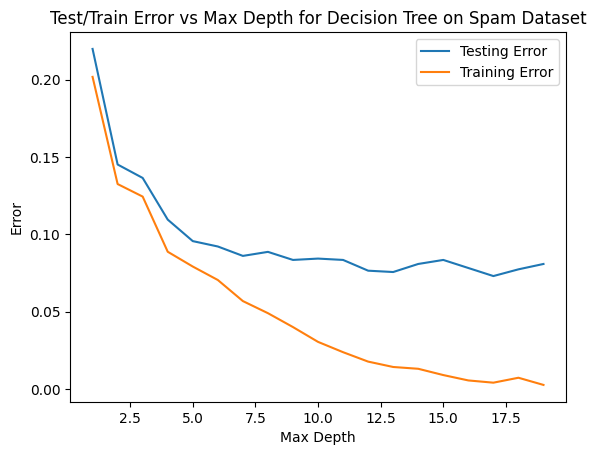

Best Test Depth: 17, error: 0.07298001737619464
Best Train Depth: 19, error: 0.00260869565217392

The best test depth is 17, with an error score of 0.07, which is good. The best train depth is 19, with an error score of 0.002, which is very good. The training error continues to decrease with more levels, while the testing error plateaus and then starts to increase again, which is a clear sign of overfitting. Both errors are high at very low depths, but the training error decreases much more significantly than the testing error as the depth increases. Overall, this graph shows that increasing the depth of the decision tree does reduce errors for both training and testing sets up to a certain point, and then it leads to overfitting.


In [25]:
import matplotlib.pyplot as plt

depths = []
train_errors = []
test_errors = []

best_train = {}
best_test = {}

for depth in range(1, 20):
    dtc_spam_depth = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    dtc_spam_depth.fit(X_train_spam, y_train_spam)
    y_pred_spam_depth = dtc_spam_depth.predict(X_test_spam)
    y_pred_spam_depth_train = dtc_spam_depth.predict(X_train_spam)
    depths.append(depth)
    train_errors.append(1 - accuracy_score(y_train_spam, y_pred_spam_depth_train))
    test_errors.append(1 - accuracy_score(y_test_spam, y_pred_spam_depth))

    if depth == 1:
        best_train["depth"] = depth
        best_train["error"] = 1 - accuracy_score(y_train_spam, y_pred_spam_depth_train)
    elif 1 - accuracy_score(y_train_spam, y_pred_spam_depth_train) < best_train["error"]:
        best_train["depth"] = depth
        best_train["error"] = 1 - accuracy_score(y_train_spam, y_pred_spam_depth_train)

    if depth == 1:
        best_test["depth"] = depth
        best_test["error"] = 1 - accuracy_score(y_test_spam, y_pred_spam_depth)
    elif 1 - accuracy_score(y_test_spam, y_pred_spam_depth) < best_test["error"]:
        best_test["depth"] = depth
        best_test["error"] = 1 - accuracy_score(y_test_spam, y_pred_spam_depth)

plt.plot(depths, test_errors, label="Testing Error")
plt.plot(depths, train_errors, label="Training Error")
plt.xlabel("Max Depth")
plt.ylabel("Error")
plt.title("Test/Train Error vs Max Depth for Decision Tree on Spam Dataset")
plt.legend()
plt.show()

print(f"Best Test Depth: {best_test['depth']}, error: {best_test['error']}")
print(f"Best Train Depth: {best_train['depth']}, error: {best_train['error']}")

print("\nThe best test depth is 17, with an error score of 0.07, which is good. The best train depth is 19, with an error score of 0.002, which is very good. The training error continues to decrease with more levels, while the testing error plateaus and then starts to increase again, which is a clear sign of overfitting. Both errors are high at very low depths, but the training error decreases much more significantly than the testing error as the depth increases. Overall, this graph shows that increasing the depth of the decision tree does reduce errors for both training and testing sets up to a certain point, and then it leads to overfitting.")

# Problem 2: Random Forest Ensemble (25 points)

1. Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the *SPAMBASE* dataset. Report
accuracy, F1 score, and AUC on both the training and testing sets for $T \in \{10, 50, 100, 500\}$. How do the metrics change as $T$
increases?
2. Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_results = []

for num_trees in [10, 50, 100, 500]:
    rfr = RandomForestClassifier(n_estimators=num_trees, random_state=42)
    rfr.fit(X_train_spam, y_train_spam)
    y_pred_rfr = rfr.predict(X_test_spam)
    y_pred_rfr_train = rfr.predict(X_train_spam)

    rf_results.append({
        "Number of Trees": num_trees,
        "Training Accuracy": accuracy_score(y_train_spam, y_pred_rfr_train.round()),
        "Testing Accuracy": accuracy_score(y_test_spam, y_pred_rfr.round()),
        "Training Error": 1 - accuracy_score(y_train_spam, y_pred_rfr_train.round()),
        "Testing Error": 1 - accuracy_score(y_test_spam, y_pred_rfr.round()),
        "Training F1": f1_score(y_train_spam, y_pred_rfr_train.round()),
        "Testing F1": f1_score(y_test_spam, y_pred_rfr.round()),
        "Training AUC": roc_auc_score(y_train_spam, y_pred_rfr_train),
        "Testing AUC": roc_auc_score(y_test_spam, y_pred_rfr)
    })

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)

print("\nMore trees yieled a better performing model, though training performance plateaued for most metrics (accuracy, F1) at 50 trees (and increased very slightly for AUC). For the testing metrics, increasing the trees also improved metrics all the way up to 500 trees. The training error was extrmely low for all tree counts, while the testing error was higher but still relatively low.")
print("\nCompared to the single decision trees, the random forest models outperformed both the gini and entropy decision trees in all metrics, even with just 10 trees. The random forest models had much higher testing accuracy, F1, and AUC than the single decision trees, and much lower testing error. This is likely because the random forest models are able to reduce overfitting by averaging the predictions of multiple trees, while the single decision trees are more prone to overfitting to the training data.")

,Number of Trees,Training Accuracy,Testing Accuracy,Training Error,Testing Error,Training F1,Testing F1,Training AUC,Testing AUC
0,10,0.995652,0.946134,0.004348,0.053866,0.994380,0.932900,0.994942,0.940371
1,50,0.999420,0.958297,0.000580,0.041703,0.999253,0.948164,0.999390,0.953230
2,100,0.999420,0.958297,0.000580,0.041703,0.999253,0.948164,0.999390,0.953230
3,500,0.999420,0.957428,0.000580,0.042572,0.999253,0.947141,0.999390,0.952490



More trees yieled a better performing model, though training performance plateaued for most metrics (accuracy, F1) at 50 trees (and increased very slightly for AUC). For the testing metrics, increasing the trees also improved metrics all the way up to 500 trees. The training error was extrmely low for all tree counts, while the testing error was higher but still relatively low.

Compared to the single decision trees, the random forest models outperformed both the gini and entropy decision trees in all metrics, even with just 10 trees. The random forest models had much higher testing accuracy, F1, and AUC than the single decision trees, and much lower testing error. This is likely because the random forest models are able to reduce overfitting by averaging the predictions of multiple trees, while the single decision trees are more prone to overfitting to the training data.


3. Compute the variable importance for each feature and include a plot.

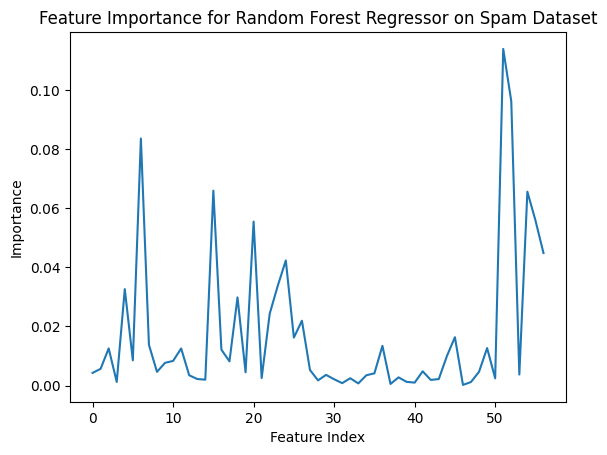

In [51]:
variable_importance = rfr.feature_importances_
plt.plot(variable_importance)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance for Random Forest Regressor on Spam Dataset")
plt.show()

# Problem 3: AdaBoost Ensemble (25 points)

1. Use an existing package to train an AdaBoost ensemble with 10, 50, 100, and 500 base classifiers on the *SPAMBASE* dataset. Use a
decision tree classifier as the base classification model. Report accuracy, F1 score, and AUC on both the training and testing sets.


In [52]:
from sklearn.ensemble import AdaBoostClassifier

ada_results = []
for num_classifiers in [10, 50, 100, 500]:
    ada = AdaBoostClassifier(n_estimators=num_classifiers, random_state=42) # decision tree is the default base estimator for AdaBoostRegressor
    ada.fit(X_train_spam, y_train_spam)
    y_pred_ada = ada.predict(X_test_spam)
    y_pred_ada_train = ada.predict(X_train_spam)

    ada_results.append({
        "Number of Classifiers": num_classifiers,
        "Training Accuracy": accuracy_score(y_train_spam, y_pred_ada_train.round()),
        "Testing Accuracy": accuracy_score(y_test_spam, y_pred_ada.round()),
        "Training Error": 1 - accuracy_score(y_train_spam, y_pred_ada_train.round()),
        "Testing Error": 1 - accuracy_score(y_test_spam, y_pred_ada.round()),
        "Training F1": f1_score(y_train_spam, y_pred_ada_train.round()),
        "Testing F1": f1_score(y_test_spam, y_pred_ada.round()),
        "Training AUC": roc_auc_score(y_train_spam, y_pred_ada_train),
        "Testing AUC": roc_auc_score(y_test_spam, y_pred_ada)
    })

ada_results_df = pd.DataFrame(ada_results)
display(ada_results_df)

/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,Number of Classifiers,Training Accuracy,Testing Accuracy,Training Error,Testing Error,Training F1,Testing F1,Training AUC,Testing AUC
0,10,0.923768,0.922676,0.076232,0.077324,0.900190,0.902944,0.916920,0.915079
1,50,0.946667,0.934839,0.053333,0.065161,0.930775,0.919614,0.942607,0.930129
2,100,0.957391,0.943527,0.042609,0.056473,0.944799,0.931217,0.954243,0.940969
3,500,0.989855,0.936577,0.010145,0.063423,0.986896,0.923077,0.988975,0.934425


2. Compare AdaBoost with the Random Forest ensemble for 10, 50, 100, and 500 base learners by looking at various metrics on the training
and testing sets.


In [57]:
rf_results_df.rename(columns={"Number of Trees": "Number of Trees/Classifiers"}, inplace=True)
ada_results_df.rename(columns={"Number of Classifiers": "Number of Trees/Classifiers"}, inplace=True)


print("\nThe random forest model had better score accross all metrics, but more discrepencies between its test and train metrics. The AdaBoost model had much more similar training and testing metrics at the lower tree counts, but the metrics themselves were all worse than the random forest's metrics. The AdaBoost model also had improving train metrics as the number of trees increased, but the testing metrics peaked at 100 trees and then began to worsen. This indicates that the AdaBoost model at a small number of trees is less overfitted than the random forest model, but it is overfitting at a higher tree number, and is also performing worse on both the training and testing data than the random forest model.")
rf_results_df.merge(ada_results_df, on='Number of Trees/Classifiers', suffixes=('_Random Forest', '_AdaBoost'))



The random forest model had better score accross all metrics, but more discrepencies between its test and train metrics. The AdaBoost model had much more similar training and testing metrics at the lower tree counts, but the metrics themselves were all worse than the random forest's metrics. The AdaBoost model also had improving train metrics as the number of trees increased, but the testing metrics peaked at 100 trees and then began to worsen. This indicates that the AdaBoost model at a small number of trees is less overfitted than the random forest model, but it is overfitting at a higher tree number, and is also performing worse on both the training and testing data than the random forest model.


,Number of Trees/Classifiers,Training Accuracy_Random Forest,Testing Accuracy_Random Forest,Training Error_Random Forest,Testing Error_Random Forest,Training F1_Random Forest,Testing F1_Random Forest,Training AUC_Random Forest,Testing AUC_Random Forest,Training Accuracy_AdaBoost,Testing Accuracy_AdaBoost,Training Error_AdaBoost,Testing Error_AdaBoost,Training F1_AdaBoost,Testing F1_AdaBoost,Training AUC_AdaBoost,Testing AUC_AdaBoost
0,10,0.995652,0.946134,0.004348,0.053866,0.994380,0.932900,0.994942,0.940371,0.923768,0.922676,0.076232,0.077324,0.900190,0.902944,0.916920,0.915079
1,50,0.999420,0.958297,0.000580,0.041703,0.999253,0.948164,0.999390,0.953230,0.946667,0.934839,0.053333,0.065161,0.930775,0.919614,0.942607,0.930129
2,100,0.999420,0.958297,0.000580,0.041703,0.999253,0.948164,0.999390,0.953230,0.957391,0.943527,0.042609,0.056473,0.944799,0.931217,0.954243,0.940969
3,500,0.999420,0.957428,0.000580,0.042572,0.999253,0.947141,0.999390,0.952490,0.989855,0.936577,0.010145,0.063423,0.986896,0.923077,0.988975,0.934425


3. Plot the ROC curves for the decision tree model, Random Forest with 100 trees, and AdaBoost with 100 trees.

/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


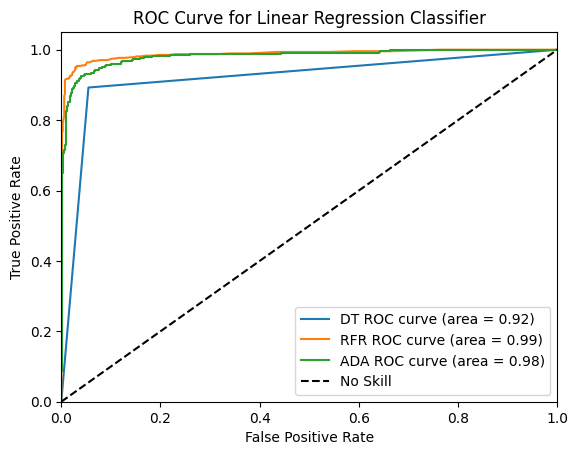

In [58]:
from sklearn.metrics import roc_curve, auc


rfr100 = RandomForestClassifier(n_estimators=100, random_state=42)
rfr100.fit(X_train_spam, y_train_spam)
y_pred_rfr100 = rfr100.predict(X_test_spam)

ada100 = AdaBoostClassifier(n_estimators=100, random_state=42)
ada100.fit(X_train_spam, y_train_spam)
y_pred_ada100 = ada100.predict(X_test_spam)


fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_spam, dtc_spam.predict_proba(X_test_spam)[:, 1]) 
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rfr100, tpr_rfr100, thresholds_rfr100 = roc_curve(y_test_spam, rfr100.predict_proba(X_test_spam)[:, 1]) 
roc_auc_rfr100 = auc(fpr_rfr100, tpr_rfr100)

fpr_ada100, tpr_ada100, thresholds_ada100 = roc_curve(y_test_spam, ada100.predict_proba(X_test_spam)[:, 1]) 
roc_auc_ada100 = auc(fpr_ada100, tpr_ada100)


# plot the ROC curve
plt.figure()  
plt.plot(fpr_dt, tpr_dt, label='DT ROC curve (area = %0.2f)' % roc_auc)
plt.plot(fpr_rfr100, tpr_rfr100, label='RFR ROC curve (area = %0.2f)' % roc_auc_rfr100)
plt.plot(fpr_ada100, tpr_ada100, label='ADA ROC curve (area = %0.2f)' % roc_auc_ada100)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Linear Regression Classifier')
plt.legend()
plt.show()


# Problem 4: Naive Bayes classifier (25 points)

In this problem you will implement your own Naive Bayes classifier and you will compare it with a package implementation. You will use the
Mushroom dataset for this problem. Split the dataset into 75% for training and 25% for testing.

1. Train the Naive Bayes classifier. Compute the prior probabilities for the `*Edible*` and `*Poisonous*` classes from the training data. For each feature $X_i$ in the dataset compute the probabilities $P[X_i = x| Y=\textit{Edible}]$, and $P[X_i = x| Y=\textit{Poisonous}]$ from the training data. Use the Laplace smoothing method when computing these probabilities. Note that the Naive Bayes classifier stores these prior and conditional probabilities.
2. For each point in the testing set estimate the probability that it belongs to the `*Edible*` and `*Poisonous*` classes. Use the Naive Bayes
classifier probabilities computed in part (1).
3. Compute accuracy, precision, recall, and F1 score for your Naive Bayes classifier on the testing data.
4. Compare the results obtained by your implementation with those obtained with a Naive Bayes package (trained on the same dataset).
Use several metrics, including accuracy, precision, recall, and F1 score. Are the results similar or different?